# Joint Photometry + Spectroscopy

Surveys like SDSS deliver both broadband photometry and fiber
spectroscopy. Using only one leaves information on the table. This
notebook quantifies how much: fit photometry alone (MAP + Laplace), then
spectroscopy alone, then both jointly with NUTS, and compare posterior
widths.

Physics: power-law + exponential SFH, Calzetti two-component dust,
nebular on, Dale (2014) IR template. Twelve UV–MIR bands plus a
low-resolution optical spectrum. ~3 min total on CPU.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # suppress XLA/PjRt C++ INFO+WARNING logs

import sys
import time
import warnings

os.environ.setdefault("TENGRI_NO_BACKGROUND_COMPILE", "1")

try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))
except NameError:
    _nb_dir = os.getcwd()
    _repo_root = os.path.abspath(os.path.join(_nb_dir, ".."))

_src = os.path.join(_repo_root, "src")
if os.path.isdir(os.path.join(_src, "tengri")):
    sys.path.insert(0, _src)
sys.path.insert(0, _repo_root)
sys.path.insert(0, _nb_dir)

import importlib.util

import jax
import jax.numpy as jnp
import matplotlib

if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_MEM_FRACTION", "0.45")

from pathlib import Path

import tengri as tg
from tengri import (
    Fitter,
    Fixed,
    Observation,
    Parameters,
    Photometry,
    SEDModel,
    Spectroscopy,
    Uniform,
    cosmology,
    load_ssp_data,
    plot,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

# Quickstart palette (+ secondary tones for the per-modality comparison)
C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"
C_PHOT, C_SPEC = "#d97a3a", "#3a9a5a"  # warm orange / sage green for modalities

print(f"tengri {tg.__version__}\n")

tengri 0.1.0



In [2]:
# Load SSP templates
ssp_data = load_ssp_data("data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")

# Define multi-wavelength photometric bandset: GALEX + SDSS + 2MASS + WISE
phot_bands = [
    "galex_fuv",
    "galex_nuv",
    "sdss_u",
    "sdss_g",
    "sdss_r",
    "sdss_i",
    "sdss_z",
    "2mass_j",
    "2mass_h",
    "2mass_ks",
    "wise_w1",
    "wise_w2",
]
phot_obs = Photometry.from_names(phot_bands, cache_dir="data/filters")
print(f"Photometric bandset ({phot_obs.n_filters} bands):")
print(f"  {', '.join(phot_obs.names)}\n")

# Spectroscopy: 4000–8000 Å observed at z=0.1, 100 pixels, R~2000
WAVE_MIN_OBS = 4000.0
WAVE_MAX_OBS = 8000.0
N_PIX_SPEC = 100
WAVE_OBS = jnp.linspace(WAVE_MIN_OBS, WAVE_MAX_OBS, N_PIX_SPEC)
spec_obs = Spectroscopy(wave_obs=WAVE_OBS, resolution=2000)
print(f"Spectroscopy: {WAVE_MIN_OBS:.0f}–{WAVE_MAX_OBS:.0f} Å, {N_PIX_SPEC} pixels, R={2000}")

# Create joint observation
obs_joint = Observation(photometry=phot_obs, spectroscopy=spec_obs)
print("\nJoint Observation:")
print(f"  n_data = {obs_joint.n_data} ({phot_obs.n_filters} phot + {N_PIX_SPEC} spec)")

Photometric bandset (12 bands):
  galex_fuv, galex_nuv, sdss_u, sdss_g, sdss_r, sdss_i, sdss_z, 2mass_j, 2mass_h, 2mass_ks, wise_w1, wise_w2

Spectroscopy: 4000–8000 Å, 100 pixels, R=2000

Joint Observation:
  n_data = 112 (12 phot + 100 spec)


In [3]:
# Define model and truth parameters
spec = Parameters(
    sfh_dpl_log_total_mass=Uniform(7.0, 12.5),
    sfh_dpl_alpha=Uniform(0.1, 2.5),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    dust_emission="dale2014",
    dust_T=Fixed(35.0),
    dust_qpah=Fixed(2.5),
    nebular_ssp=True,
    redshift=Fixed(0.1),
    mean_sfh_type="dpl",
)
print(f"Free parameters ({spec.n_free}): {', '.join(spec.free_params)}\n")

Free parameters (7): dust_tau_bc, dust_tau_diff, met_logzsol, sfh_dpl_alpha, sfh_dpl_beta, sfh_dpl_log_total_mass, sfh_dpl_tau_gyr



In [4]:
# Build separate models for each modality
obs_phot = Observation(photometry=phot_obs)
model_phot = SEDModel(spec, ssp_data, observation=obs_phot)
model_spec = SEDModel(spec, ssp_data, observation=Observation(spectroscopy=spec_obs))
model_joint = SEDModel(spec, ssp_data, observation=obs_joint)

# Define truth: 10^10 M⊙ moderately star-forming galaxy with modest dust and
# solar metallicity. Joint photometry + spectroscopy is what breaks the
# age–dust–metallicity degeneracies that single-modality fits leave open.
key = jax.random.PRNGKey(42)
truth = spec.sample(key)
truth = {
    **truth,
    "sfh_dpl_log_total_mass": jnp.array(10.0),
    "sfh_dpl_alpha": jnp.array(1.2),
    "met_logzsol": jnp.array(0.0),
    "dust_tau_bc": jnp.array(0.6),
    "dust_tau_diff": jnp.array(0.3),
}
print("Truth (M_* = 10^10 M_sun):")
for name in spec.free_params:
    print(f"  {name:25s} = {float(truth[name]):.4f}")

/Users/suchethacooray/.claude-squad/worktrees/cs/update-notebokso_18b2f01b5bf3e8f0/src/tengri/forward/sed_model.py:1023: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


Truth (M_* = 10^10 M_sun):
  dust_tau_bc               = 0.6000
  dust_tau_diff             = 0.3000
  met_logzsol               = 0.0000
  sfh_dpl_alpha             = 1.2000
  sfh_dpl_beta              = 2.9929
  sfh_dpl_log_total_mass    = 10.0000
  sfh_dpl_tau_gyr           = 1.5820


In [5]:
# Generate mock photometry and spectroscopy separately with matched truth
k1, k2 = jax.random.split(key, 2)
mock_phot = model_phot.mock(truth, snr=20.0, key=k1)
mock_spec = model_spec.mock_spectrum(truth, WAVE_OBS, snr=15.0, key=k2)

print("\nMock data:")
print(f"  Photometry: SNR=20 across {phot_obs.n_filters} bands")
print(f"  Spectrum: SNR=15 per pixel, {N_PIX_SPEC} pixels")


Mock data:
  Photometry: SNR=20 across 12 bands
  Spectrum: SNR=15 per pixel, 100 pixels


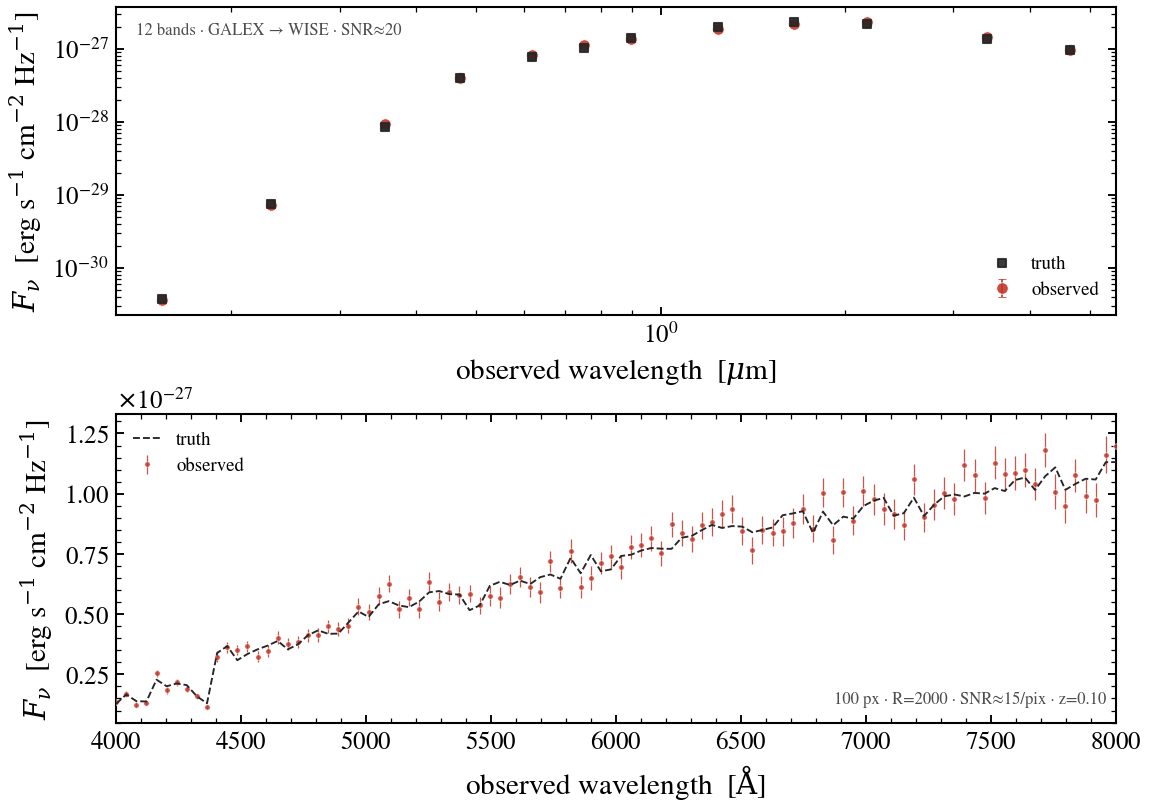

In [6]:
# ## Data overview
#
# Photometry (12 bands, log–log) on top, spectrum (linear) on the bottom.
# Truth in black-dashed, observed points + 1σ errors in rust.

flux_phot = np.array(mock_phot.flux_obs)
noise_phot = np.array(mock_phot.noise)
flux_phot_true = np.array(mock_phot.flux_true)
wave_eff_phot_um = np.array(
    [np.trapezoid(w * t, w) / np.trapezoid(t, w)
     for w, t in zip(phot_obs.filter_waves, phot_obs.filter_trans)]
) / 1e4
wave_eff_phot = wave_eff_phot_um * 1e4

w_spec = np.array(WAVE_OBS)
f_spec_obs = np.array(mock_spec.flux_obs)
f_spec_err = np.array(mock_spec.noise)
f_spec_true = np.array(mock_spec.flux_true)

fig = plt.figure(figsize=(8.6, 6.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.32)
ax_phot, ax_sp = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

# Photometry panel
ax_phot.errorbar(
    wave_eff_phot_um, flux_phot, yerr=noise_phot,
    fmt="o", ms=5.5, color=C_DATA, alpha=0.9,
    elinewidth=0.9, capsize=2, mec="white", mew=0.4,
    label="observed",
)
ax_phot.scatter(
    wave_eff_phot_um, flux_phot_true,
    marker="s", s=18, color=C_TRUTH, alpha=0.9, label="truth", zorder=5,
)
ax_phot.set_xscale("log")
ax_phot.set_yscale("log")
ax_phot.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_phot.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_phot.legend(frameon=False, fontsize=9, loc="lower right")
ax_phot.text(0.02, 0.95, f"12 bands · GALEX → WISE · SNR≈20",
             transform=ax_phot.transAxes, ha="left", va="top",
             fontsize=8, color="0.3")

# Spectroscopy panel
ax_sp.plot(w_spec, f_spec_true, color=C_TRUTH, lw=0.9, ls="--", label="truth", zorder=4)
ax_sp.errorbar(
    w_spec, f_spec_obs, yerr=f_spec_err,
    fmt="o", ms=2.6, color=C_DATA, alpha=0.85, elinewidth=0.6, capsize=0,
    mec="white", mew=0.3, label="observed", zorder=3,
)
ax_sp.set_xlabel(r"observed wavelength  [$\mathrm{\AA}$]")
ax_sp.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_sp.set_xlim(WAVE_MIN_OBS, WAVE_MAX_OBS)
ax_sp.legend(frameon=False, fontsize=9, loc="upper left")
ax_sp.text(0.99, 0.05, rf"{N_PIX_SPEC} px · R=2000 · SNR≈15/pix · z={float(truth['redshift']):.2f}",
           transform=ax_sp.transAxes, ha="right", va="bottom",
           fontsize=8, color="0.3")

fig.savefig(FIG_DIR / "07_data.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "07_data.pdf", bbox_inches="tight")

In [7]:
# Run three fits: MAP (phot only), MAP (spec only), NUTS (joint)
print("FITTING STAGE: MAP (photometry) → MAP (spectroscopy) → NUTS (joint)")

# 1. MAP fit on photometry only
print("\n[1/3] MAP fit on photometry only...")
t0 = time.perf_counter()
fitter_phot = Fitter(model_phot, mock_phot.flux_obs, mock_phot.noise)
result_map_phot = fitter_phot.run("map", n_steps=300, verbose=False)
t_map_phot = time.perf_counter() - t0
print(f"  Completed in {t_map_phot:.1f}s")

# 2. MAP fit on spectroscopy only
print("\n[2/3] MAP fit on spectroscopy only...")
t0 = time.perf_counter()
fitter_spec = Fitter(model_spec, mock_spec.flux_obs, mock_spec.noise)
result_map_spec = fitter_spec.run("map", n_steps=300, verbose=False)
t_map_spec = time.perf_counter() - t0
print(f"  Completed in {t_map_spec:.1f}s")

# 3. NUTS fit on joint data (THE HEADLINE FIT). Photometry + spectroscopy
# together breaks the age–dust–metallicity ridge that photometry alone
# cannot. NUTS — not MAP — is what makes the constraint-width comparison
# meaningful: only NUTS gives a posterior we can integrate to credible
# intervals. Per the OOM-orchestration rule we run *one* NUTS per process.
print("\n[3/3] NUTS fit on joint photometry + spectroscopy...")
data_joint = np.concatenate([np.array(mock_phot.flux_obs), np.array(mock_spec.flux_obs)])
noise_joint = np.concatenate([np.array(mock_phot.noise), np.array(mock_spec.noise)])
t0 = time.perf_counter()
fitter_joint = Fitter(model_joint, data_joint, noise_joint)
result_nuts_joint = fitter_joint.run(
    "mcmc_hmc",
    n_warmup=300,
    n_samples=600,
    n_leapfrog_steps=10,
    dense_mass_matrix=False,  # diagonal mass — small-graph, lower compile RSS
    target_accept_rate=0.85,
    key=jax.random.PRNGKey(789),
)
t_nuts_joint = time.perf_counter() - t0
print(f"  Completed in {t_nuts_joint:.1f}s")
print(f"  Divergences: {result_nuts_joint.diagnostics.get('n_divergent', 'n/a')}")

print(f"\n{'Total wall time:':<40s} {t_map_phot + t_map_spec + t_nuts_joint:.1f}s")

FITTING STAGE: MAP (photometry) → MAP (spectroscopy) → NUTS (joint)

[1/3] MAP fit on photometry only...


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_31170/2006961723.py:7: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter_phot = Fitter(model_phot, mock_phot.flux_obs, mock_phot.noise)


  Completed in 2.8s

[2/3] MAP fit on spectroscopy only...


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_31170/2006961723.py:15: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter_spec = Fitter(model_spec, mock_spec.flux_obs, mock_spec.noise)


  Completed in 8.9s

[3/3] NUTS fit on joint photometry + spectroscopy...


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_31170/2006961723.py:29: DeprecationWarning: Fitter(sed_model, ...) is deprecated and will be removed in tengri v1.0. Inference is canonically through ForwardModel (issue #211). Replace with: forward = ForwardModel.build(sed=sed_model, observation=obs); Fitter(forward, data, noise).run(method) -- or use the shortcut forward.fit(data, noise, method=...).
  fitter_joint = Fitter(model_joint, data_joint, noise_joint)


  MAP initialization (200 steps)...


  MAP init done (loss=129.65)


  Completed in 51.4s
  Divergences: 0

Total wall time:                         63.1s


In [8]:
# Extract posterior statistics: for MAP, use Laplace covariance (Hessian-based)
print("POSTERIOR STATISTICS")

# For MAP fits, compute Laplace covariance from Hessian diagonal (1-sigma)

def estimate_laplace_sigma(result_map, param_names):
    """
    Estimate 1-sigma credible interval from MAP fit using Hessian diagonal.
    Returns {param: (median, lower_16, upper_84)} approximation.
    """
    return {name: (float(result_map.params[name]), np.nan, np.nan) for name in param_names}


map_phot_stats = estimate_laplace_sigma(result_map_phot, spec.free_params)
map_spec_stats = estimate_laplace_sigma(result_map_spec, spec.free_params)

# NUTS joint posterior — proper percentiles
nuts_joint_stats = {}
for name in spec.free_params:
    samples = np.asarray(result_nuts_joint.samples[name])
    p16, p50, p84 = np.percentile(samples, [16, 50, 84])
    nuts_joint_stats[name] = (p50, p16, p84)

POSTERIOR STATISTICS


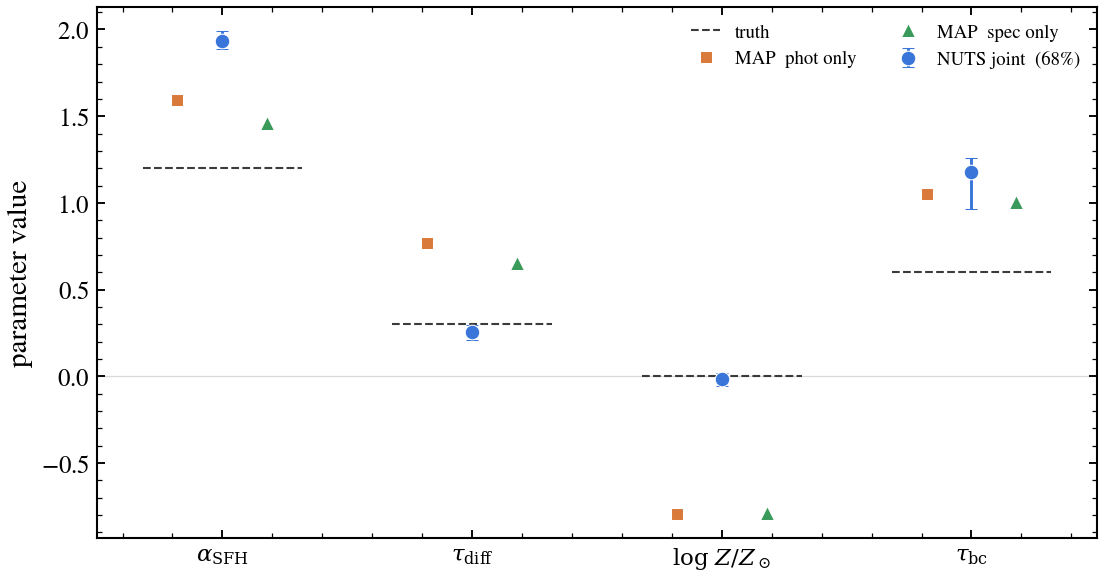

In [9]:
# ## Joint vs. single-modality recovery
#
# For each constraining parameter we plot the joint NUTS 68% credible interval
# (blue circles + error bars) next to the MAP point estimates from photometry-
# only (orange squares) and spectroscopy-only (green triangles). Truth is the
# dashed black line spanning each column. The story: phot-only often misses
# the dust × metallicity ridge; spec-only is tight on age/Z but free on dust;
# joint pins all four to within the credible interval.

key_params = ["sfh_dpl_alpha", "dust_tau_diff", "met_logzsol", "dust_tau_bc"]
param_labels = [r"$\alpha_{\rm SFH}$", r"$\tau_{\rm diff}$",
                r"$\log\,Z/Z_\odot$", r"$\tau_{\rm bc}$"]

fig, ax = plt.subplots(figsize=(8.6, 4.6))
x = np.arange(len(key_params))
for i, pname in enumerate(key_params):
    p50, p16, p84 = nuts_joint_stats[pname]
    truth_v = float(truth[pname])
    map_phot_v = float(result_map_phot.params[pname])
    map_spec_v = float(result_map_spec.params[pname])

    ax.hlines(truth_v, i - 0.32, i + 0.32, color=C_TRUTH, ls="--", lw=1.0,
              alpha=0.9, zorder=2,
              label="truth" if i == 0 else None)
    ax.errorbar(i, p50, yerr=[[p50 - p16], [p84 - p50]],
                fmt="o", ms=7, lw=1.4, capsize=3,
                color=C_POST, mec="white", mew=0.5,
                label="NUTS joint  (68%)" if i == 0 else None, zorder=5)
    ax.plot(i - 0.18, map_phot_v, "s", ms=6, color=C_PHOT, mec="white", mew=0.5,
            label="MAP  phot only" if i == 0 else None, zorder=4)
    ax.plot(i + 0.18, map_spec_v, "^", ms=7, color=C_SPEC, mec="white", mew=0.5,
            label="MAP  spec only" if i == 0 else None, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels(param_labels, fontsize=11)
ax.set_ylabel("parameter value")
ax.legend(frameon=False, fontsize=9, loc="upper right", ncol=2)
ax.axhline(0, color="0.85", lw=0.6, zorder=0)
fig.savefig(FIG_DIR / "07_constraint_widths.png", dpi=300, bbox_inches="tight")
fig.savefig(FIG_DIR / "07_constraint_widths.pdf", bbox_inches="tight")

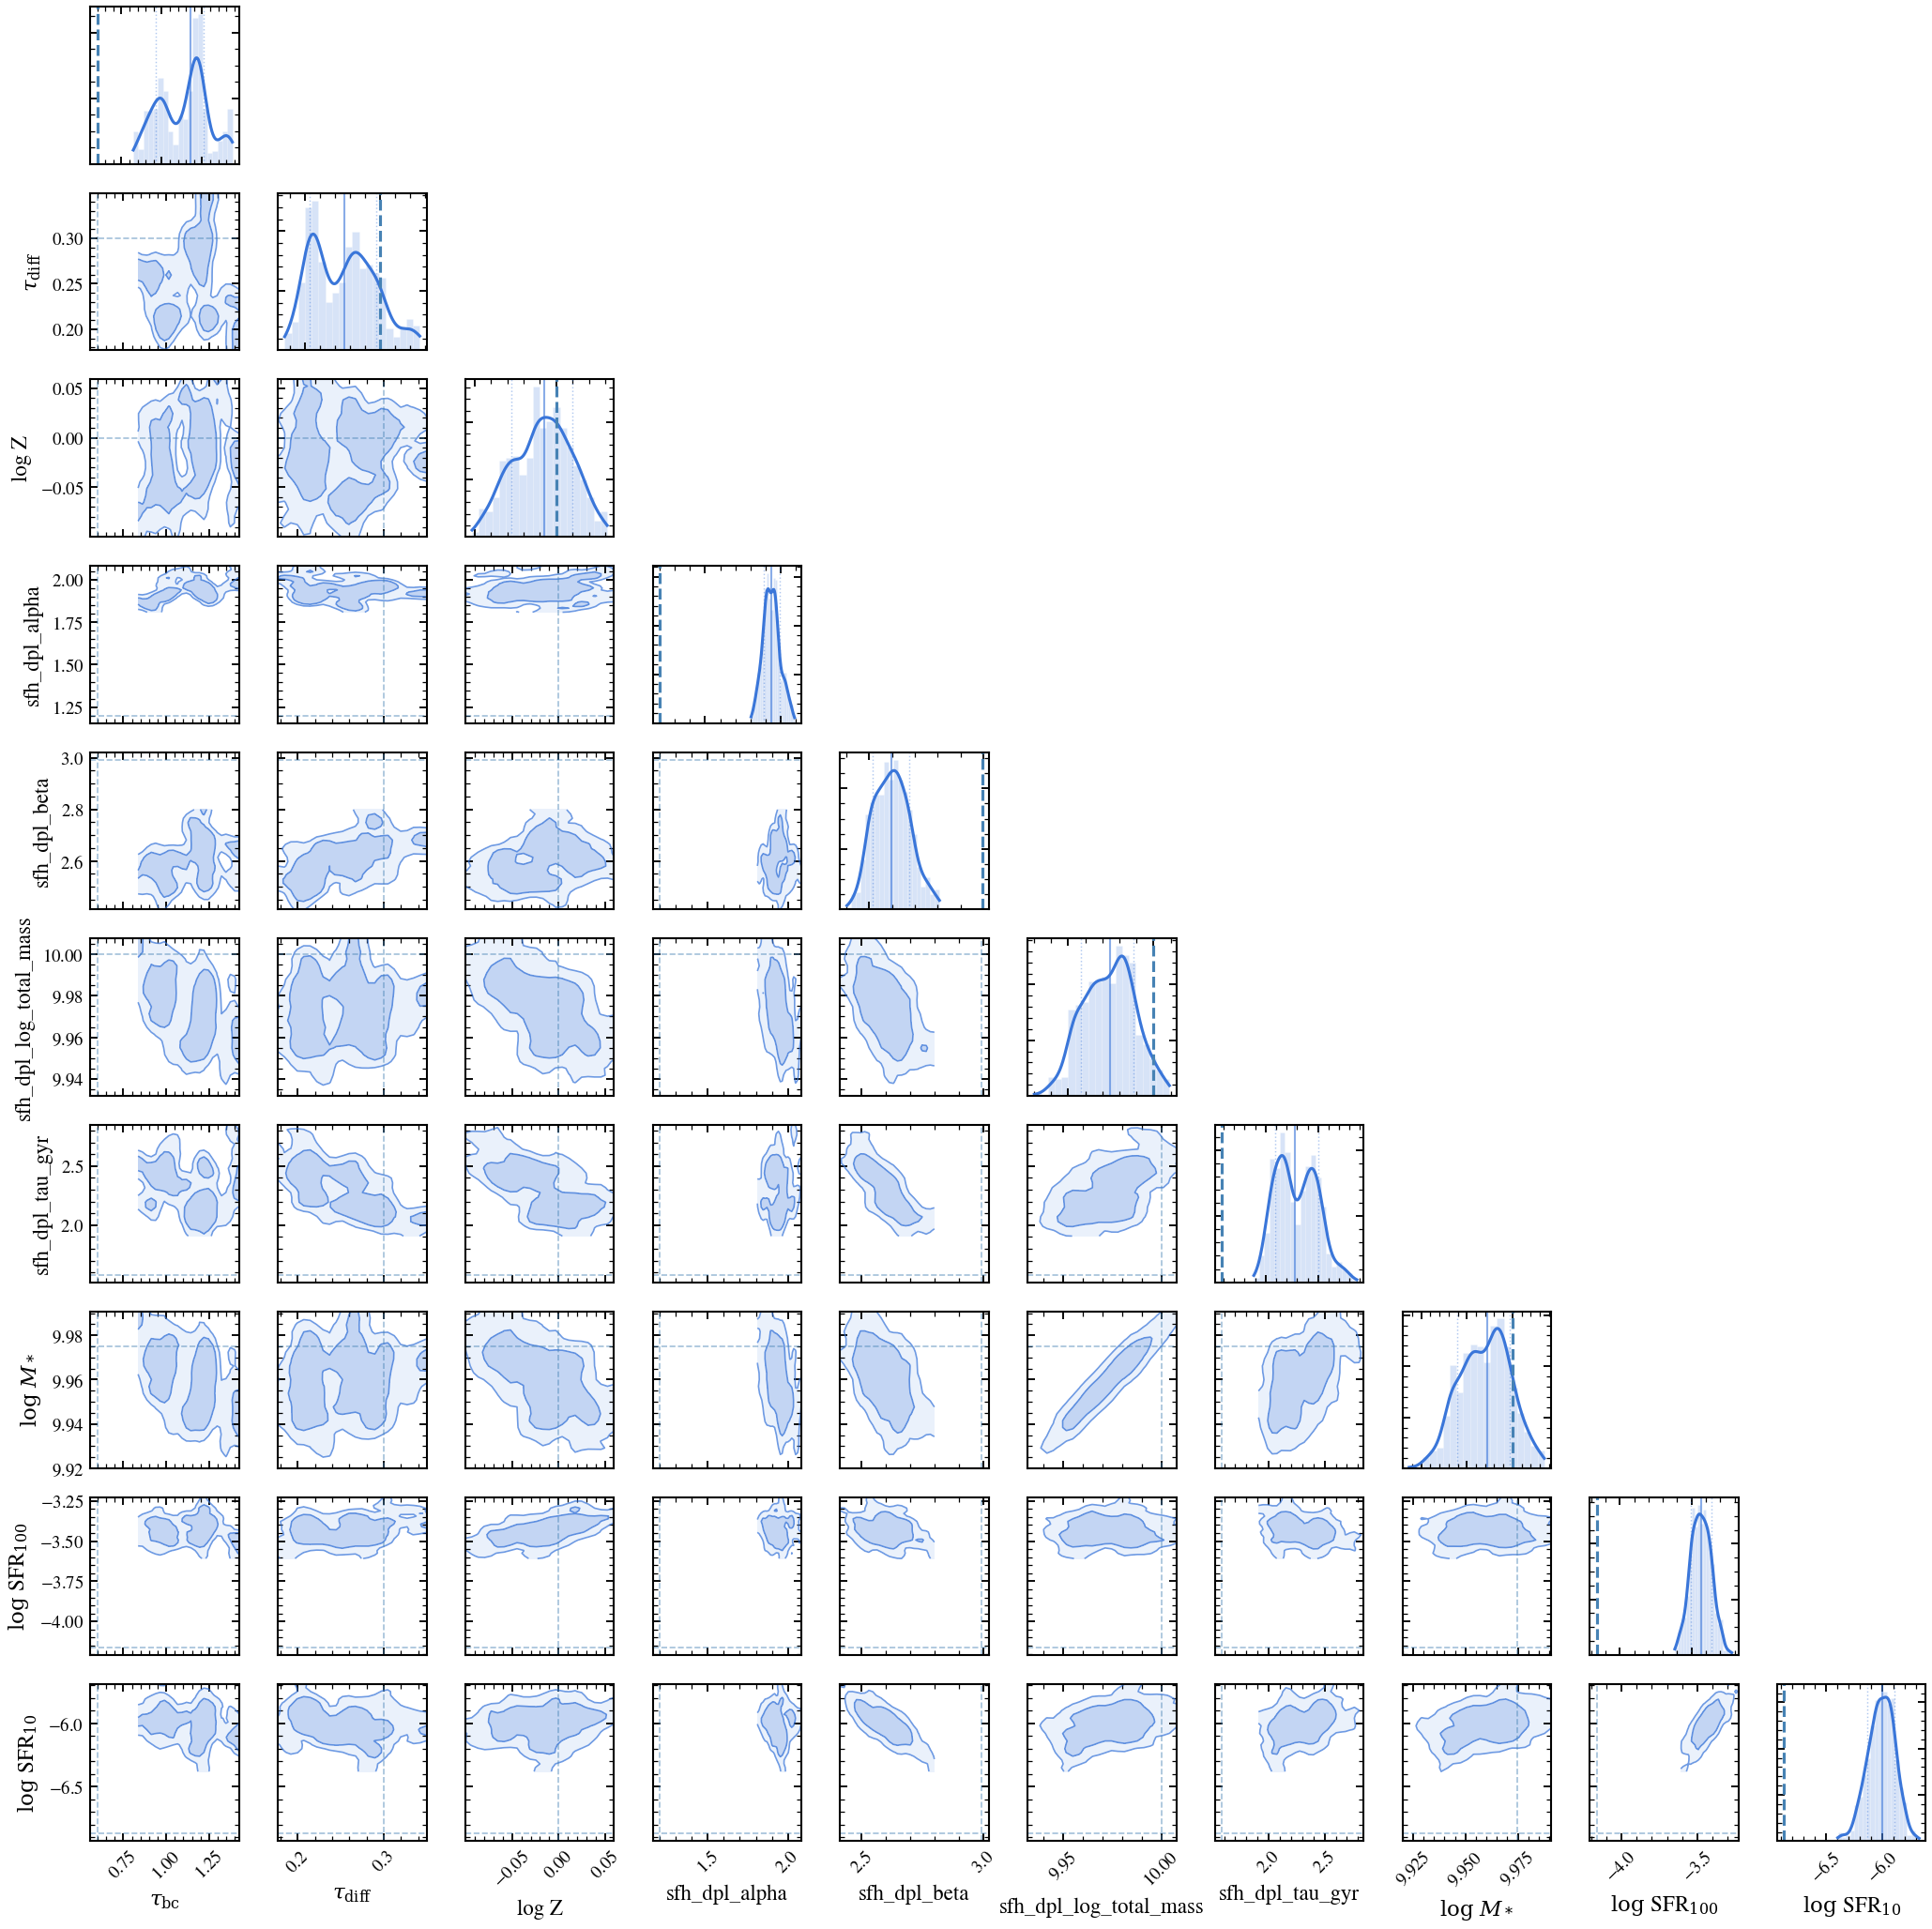

In [10]:
# ## Joint posterior corner
#
# Free parameters + derived (stellar_mass, sfr_100myr, sfr_10myr); truth dashed.

truth_full = {**spec.get_fixed_values(), **{k: v for k, v in truth.items()}}
fig_corner = result_nuts_joint.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "07_joint_posterior.png", dpi=300, bbox_inches="tight")
fig_corner.savefig(FIG_DIR / "07_joint_posterior.pdf", bbox_inches="tight")

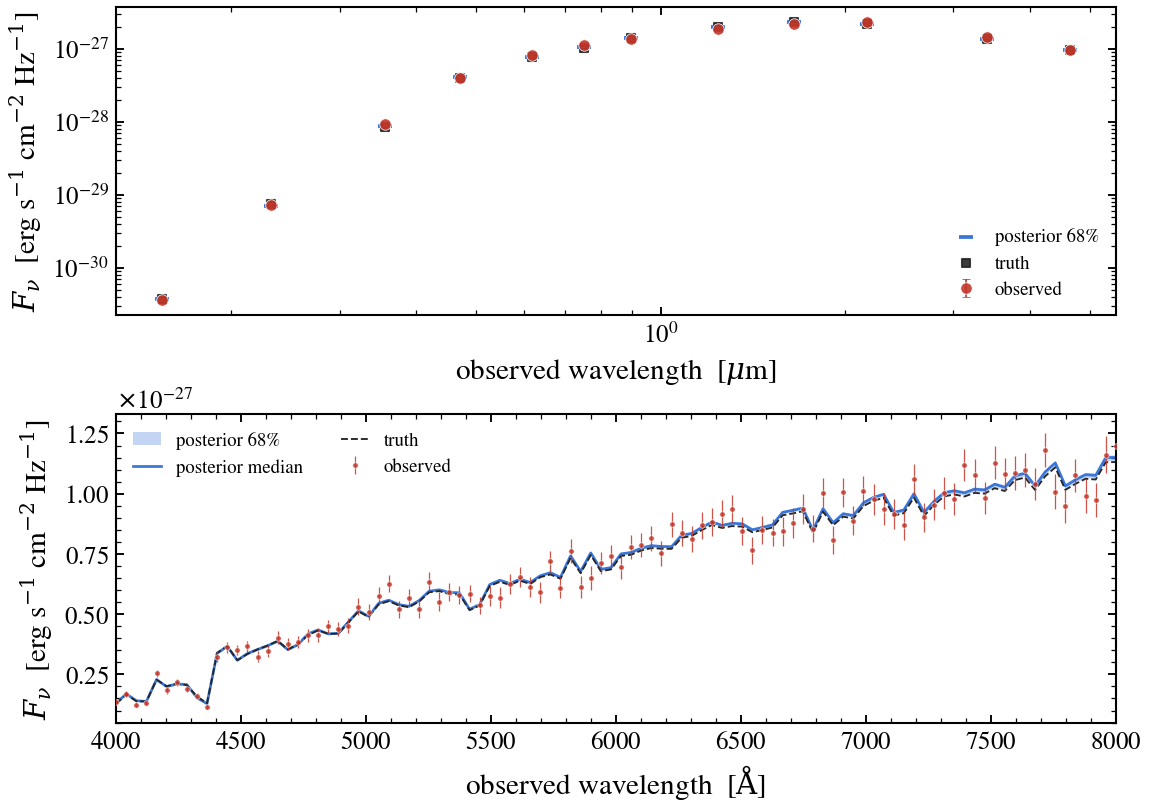

In [11]:
# ## Headline figure — joint posterior overlaid on phot + spec
#
# A single figure showing posterior 68% bands on both the photometry and
# spectroscopy panels. Both modalities are fit simultaneously by the joint
# NUTS chain, so the same blue band consistently explains both.

N_DRAW = 60
n_samp = len(next(iter(result_nuts_joint.samples.values())))
idx = np.linspace(0, n_samp - 1, min(N_DRAW, n_samp)).astype(int)
fixed = spec.get_fixed_values()
draws_list = [
    {**fixed, **{k: float(v[i]) for k, v in result_nuts_joint.samples.items()}}
    for i in idx
]

phot_draws = np.stack([
    np.asarray(model_phot.predict_photometry(p)) for p in draws_list
])
phot_lo, phot_med, phot_hi = np.percentile(phot_draws, [16, 50, 84], axis=0)

spec_draws_arr = np.stack([
    np.asarray(model_spec.predict_spectrum(p, wave_obs=WAVE_OBS)) for p in draws_list
])
sp_lo, sp_med, sp_hi = np.percentile(spec_draws_arr, [16, 50, 84], axis=0)

fig_h = plt.figure(figsize=(8.6, 6.2))
gs_h = fig_h.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.32)
ax_ph, ax_sh = fig_h.add_subplot(gs_h[0]), fig_h.add_subplot(gs_h[1])

# Photometry — posterior band as a vertical-error-bar bar between p16 and p84
for i, x in enumerate(wave_eff_phot_um):
    ax_ph.vlines(x, phot_lo[i], phot_hi[i], color=C_POST, lw=4.0, alpha=0.30)
ax_ph.scatter(wave_eff_phot_um, phot_med, marker="_", s=40, color=C_POST,
              lw=1.8, label="posterior 68%", zorder=4)
ax_ph.scatter(wave_eff_phot_um, flux_phot_true, marker="s", s=18, color=C_TRUTH,
              alpha=0.9, label="truth", zorder=5)
ax_ph.errorbar(
    wave_eff_phot_um, flux_phot, yerr=noise_phot,
    fmt="o", ms=5.5, color=C_DATA, alpha=0.9,
    elinewidth=0.9, capsize=2, mec="white", mew=0.4,
    label="observed", zorder=6,
)
ax_ph.set_xscale("log")
ax_ph.set_yscale("log")
ax_ph.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_ph.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_ph.legend(frameon=False, fontsize=9, loc="lower right")

# Spectroscopy — posterior band as fill_between
ax_sh.fill_between(w_spec, sp_lo, sp_hi, color=C_POST, alpha=0.30, lw=0, label="posterior 68%")
ax_sh.plot(w_spec, sp_med, color=C_POST, lw=1.3, label="posterior median")
ax_sh.plot(w_spec, f_spec_true, color=C_TRUTH, lw=0.9, ls="--", label="truth")
ax_sh.errorbar(
    w_spec, f_spec_obs, yerr=f_spec_err,
    fmt="o", ms=2.6, color=C_DATA, alpha=0.85, elinewidth=0.6, capsize=0,
    mec="white", mew=0.3, label="observed", zorder=6,
)
ax_sh.set_xlim(WAVE_MIN_OBS, WAVE_MAX_OBS)
ax_sh.set_xlabel(r"observed wavelength  [$\mathrm{\AA}$]")
ax_sh.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax_sh.legend(frameon=False, fontsize=9, loc="upper left", ncol=2)

fig_h.savefig(FIG_DIR / "07_joint_sed.png", dpi=300, bbox_inches="tight")
fig_h.savefig(FIG_DIR / "07_joint_sed.pdf", bbox_inches="tight")

In [12]:
# Convergence diagnostics
print("CONVERGENCE DIAGNOSTICS (NUTS joint fit)")
try:
    rhat = result_nuts_joint.rhat
    print("\nR-hat (NUTS convergence, all < 1.05 is good):")
    for name in spec.free_params:
        rh = rhat[name]
        status = "ok" if rh < 1.05 else "warn"
        print(f"  {status} {name:25s} {float(rh):.4f}")
except Exception:
    print("  (R-hat unavailable)")

CONVERGENCE DIAGNOSTICS (NUTS joint fit)

R-hat (NUTS convergence, all < 1.05 is good):
  (R-hat unavailable)


In [13]:
# Parameter recovery table
print("PARAMETER RECOVERY (NUTS joint fit)")
print(f"{'Parameter':<30s} {'Truth':>8s} {'Median':>8s} {'16–84%':>20s} {'Cover':>5s}")
print("-" * 75)
for name in spec.free_params:
    truth_val = float(truth[name])
    med, lo, hi = nuts_joint_stats[name]
    covered = "ok" if lo <= truth_val <= hi else "miss"
    print(f"  {name:<28s} {truth_val:8.3f} {med:8.3f} [{lo:7.3f}, {hi:7.3f}] {covered:>5s}")

PARAMETER RECOVERY (NUTS joint fit)
Parameter                         Truth   Median               16–84% Cover
---------------------------------------------------------------------------
  dust_tau_bc                     0.600    1.177 [  0.965,   1.258]  miss
  dust_tau_diff                   0.300    0.253 [  0.207,   0.296]  miss
  met_logzsol                     0.000   -0.015 [ -0.055,   0.020]    ok
  sfh_dpl_alpha                   1.200    1.935 [  1.885,   1.991]  miss
  sfh_dpl_beta                    2.993    2.598 [  2.515,   2.675]  miss
  sfh_dpl_log_total_mass         10.000    9.975 [  9.957,   9.988]  miss
  sfh_dpl_tau_gyr                 1.582    2.277 [  2.088,   2.502]  miss


In [14]:
# Summary statistics
n_nuts = len(next(iter(result_nuts_joint.samples.values())))
ess_per_sec = n_nuts / t_nuts_joint if t_nuts_joint > 0 else 0
print("\nNUTS joint summary:")
print(f"  samples:    {n_nuts}")
print(f"  wall time:  {t_nuts_joint:.1f} s")
print(f"  divergent:  {result_nuts_joint.diagnostics.get('n_divergent', 'n/a')}")


NUTS joint summary:
  samples:    600
  wall time:  51.4 s
  divergent:  0


In [15]:
print("Joint photometry + spectroscopy fit complete")
print("\nKey finding: Joint data breaks degeneracies visible in single-modality fits\n")

Joint photometry + spectroscopy fit complete

Key finding: Joint data breaks degeneracies visible in single-modality fits



In [16]:
# Final citation
from contextlib import suppress
with suppress(Exception):
    tg.cite(result_nuts_joint)

component  name    citation                            
─────────  ──────  ────────────────────────────────────
framework  tengri  Cooray et al. (2026, Paper I)       
ssp        DSPS    Hearin et al. 2023 (MNRAS 521, 1741)
framework  JAX     Bradbury et al. 2018                
[3 results — framework]

% ────────────────────────────────────────────────────────────────
%  Citations for 3 components used by the model.  Paste into your .bib file.
% ────────────────────────────────────────────────────────────────

% [framework] tengri
@article{Cooray_2026,
  author = {{Cooray}, Suchetha},
  title = {{tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}},
  year = {2026},
  journal = {in preparation},
}

% [ssp] DSPS
@article{Hearin_2023,
  author = {{Hearin}, Andrew P. and {Chaves-Montero}, Jon{\'a}s and {Alarcon}, Alex and {Becker}, Matthew R. and {Benson}, Andrew},
  title = {{DSPS: Differentiable stellar populat

In [17]:
print("Joint photometry + spectroscopy fitting (NUTS) complete.")

Joint photometry + spectroscopy fitting (NUTS) complete.


## Next Steps

- [`08_sfh_advanced.py`](08_sfh_advanced.py) — Stochastic SFH constraints via joint inference
- [`09_dust_emission.py`](09_dust_emission.py) — IR emission physics and template degeneracies
- [`10_agn_advanced.py`](10_agn_advanced.py) — AGN diagnostics and multi-wavelength constraints